
## 01MIAR - Actividad Video Valencia Pollution

## NumPy y Pandas

### Objetivos:
- Aplicar diferentes técnicas de tratamiento de estructuras numéricas con Numpy y datos estructurados con Pandas.

### Instrucciones:
- Mantener una estructura limpia, comentando código y secuenciando los apartados con el código correspondiente que resuelva la actividad.
- Como criterio de evaluación se tendrá en cuenta el resultado, la consecución del mismo, estilo, comentarios y adecuación. Siempre será tenido en cuenta cualquier detalle técnico avanzado o no visto en clase relacionado con el tema (explicar el porqué y usabilidad).
- No está permitido compartir los resultados ni el código en ninguno de los foros.
- Revisar los temas así como las sesiones sobre Numpy y Pandas para aplicar dichos contenidos.
- Proponer las respuestas en las celdas a dicho efecto en cada punto, si se necesitan más celdas añadirlas en su sitio correspondiente
- Mostrar de manera clara la respuesta a las preguntas, mediante código

### Entrega:
- Este mismo notebook con las respuetas

### Evaluación
- Esta actividad corresponde con el 10% de la nota final de la asignatura.

### Fecha Realización
- Convocatoria 1 - 30/06/2025

#### Descripción
El conjunto de datos "valencia_pollution_dataset.csv" (fichero disponible adjunto a la actividad) proviene de una descarga de datos del servicio web del ayuntamiento de la ciudad de Valencia de datos abiertos.

Los datos recabados de este servicio web son de mediciones cada hora de una serie de estaciones de contaminación atmosférica.

https://valencia.opendatasoft.com/explore/dataset/estacions-contaminacio-atmosferiques-estaciones-contaminacion-atmosfericas/information/

Cada estación realiza una serie de mediciones acerca de la calidad del aire, y de ciertas sustancias que se consideran importantes para analizar la contaminación atmosférica en la ciudad.

#### Columnas para trabajar:
- objectid: id de la estación
- nombre: nombre de la estación
- dirección: dirección de la estación
- tipozona: tipo de la zona, urbana o sub urbana
- parámetros: parámetroe medidos
- mediciones: fichero de mediciones
- tipoemision: tráfico o fondo
- so2: niveles de dióxido de azufre
- no2: niveles de dióxido de nitrogeno
- o3: niveles de ozono
- co: niveles de monóxido de carbono
- pm10: niveles de partículas en suspensión hasta 10um
- pm25: niveles de partículas en suspensión hasta 2,5um
- fecha_carga: timestamp de la actualización de los datos
- calidad_ambiental: estimación de la calidad del aire
- fiwareid:
- geo_shape: coordenadas geográficas
- geo_point_2d: latitud-longitud

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from io import StringIO

In [ ]:
def make_request(base_url, params):
  response = requests.get(base_url, params=params)
  if response:
    return response.json()
  else:
    return Exception("Error al consultar la API")

In [ ]:
base_url = "https://valencia.opendatasoft.com/api/explore/v2.1/catalog/datasets/estacions-contaminacio-atmosferiques-estaciones-contaminacion-atmosfericas/records"

params = {'limit' : 0}
n_stations = make_request(base_url, params)['total_count']
print(f"Numero total de estaciones = {n_stations}")

Numero total de estaciones = 0


## 01
Carga de datos de csv (valencia_pollution_dataset.csv) en un DataFrame

In [ ]:
# Abre un cuadro de diálogo para subir el cvs desde Google Colab
csv_file = files.upload()

# Obtiene el nombre del archivo subido
csv = list(csv_file.keys())[0]

Saving valencia_pollution_dataset.csv to valencia_pollution_dataset (2).csv


In [ ]:
# Lee el archivo CSV y carga las columnas seleccionadas
df = pd.read_csv(
    csv,
    usecols=[
        'objectid',
        "nombre",
        "direccion",
        "tipozona",
        "parametros",
        "mediciones",
        "so2",
        "no2",
        "o3",
        "co",
        "pm10",
        "pm25",
        "tipoemision",
        "fecha_carga",
        "calidad_ambiental",
        "fiwareid",
        "geo_shape",
        "geo_point_2d"
    ]
)

# Muestra las primeras 5 filas del DataFrame
display(df.head(5))

,objectid,nombre,direccion,tipozona,parametros,mediciones,so2,no2,o3,co,pm10,pm25,tipoemision,fecha_carga,calidad_ambiental,fiwareid,geo_shape,geo_point_2d
0,26,Pista de Silla,"C/ Filipinas, s/n",Urbana,NaN,NaN,0.0,10,71.0,0.7,8.0,3.0,Tráfico,2025-05-24T20:20:06+00:00,Razonablemente Buena,NaN,NaN,NaN
1,28,Viveros,Jardines de Viveros,Urbana,NaN,NaN,0.0,5,88.0,NaN,NaN,NaN,Fondo,2025-05-24T20:20:08+00:00,Razonablemente Buena,NaN,NaN,NaN
2,431,Olivereta,Av. del Cid amb Av. de les Tres Creus,Urbana,NaN,NaN,NaN,24,NaN,NaN,20.0,11.0,Tráfico,2025-05-24T20:20:11+00:00,Razonablemente Buena,NaN,NaN,NaN
3,432,Patraix,"Archiduque Carlos, 84ac",Urbana,NaN,NaN,NaN,15,NaN,NaN,20.0,11.0,Tráfico,2025-05-24T20:20:12+00:00,Razonablemente Buena,NaN,NaN,NaN
4,23,Francia,"Avda. de Francia, 60",Urbana,NaN,NaN,1.0,3,82.0,0.1,9.0,6.0,Tráfico,2025-05-24T20:20:04+00:00,Razonablemente Buena,NaN,NaN,NaN


Hacemos display info para vrificar el tipo de variables que tenemos y los datos que se contienen, como por ejemplo validar los NaN.

In [ ]:
display(df.info()) # Muestra información general del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   objectid           396 non-null    int64  
 1   nombre             396 non-null    object 
 2   direccion          396 non-null    object 
 3   tipozona           396 non-null    object 
 4   parametros         0 non-null      float64
 5   mediciones         0 non-null      float64
 6   so2                216 non-null    float64
 7   no2                396 non-null    int64  
 8   o3                 216 non-null    float64
 9   co                 108 non-null    float64
 10  pm10               288 non-null    float64
 11  pm25               288 non-null    float64
 12  tipoemision        396 non-null    object 
 13  fecha_carga        396 non-null    object 
 14  calidad_ambiental  396 non-null    object 
 15  fiwareid           0 non-null      float64
 16  geo_shape          0 non-n

None

In [ ]:
display(df.describe(include='all')) # Muestra un resumen estadístico de todas las columnas del DataFrame

,objectid,nombre,direccion,tipozona,parametros,mediciones,so2,no2,o3,co,pm10,pm25,tipoemision,fecha_carga,calidad_ambiental,fiwareid,geo_shape,geo_point_2d
count,396.000000,396,396,396,0.0,0.0,216.000000,396.000000,216.0000,108.000000,288.000000,288.000000,396,396,396,0.0,0.0,0.0
unique,NaN,11,11,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,315,2,NaN,NaN,NaN
top,NaN,Pista de Silla,"C/ Filipinas, s/n",Urbana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tráfico,2025-05-26T10:20:07+00:00,Razonablemente Buena,NaN,NaN,NaN
freq,NaN,36,36,324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,288,2,296,NaN,NaN,NaN
mean,208.818182,NaN,NaN,NaN,NaN,NaN,1.449074,8.921717,71.0000,0.366667,14.687500,8.031250,NaN,NaN,NaN,NaN,NaN,NaN
std,264.784847,NaN,NaN,NaN,NaN,NaN,1.400066,6.453058,13.0662,0.250607,6.258061,3.224859,NaN,NaN,NaN,NaN,NaN,NaN
min,22.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,36.0000,0.100000,6.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,24.000000,NaN,NaN,NaN,NaN,NaN,0.000000,4.000000,63.0000,0.100000,7.000000,5.750000,NaN,NaN,NaN,NaN,NaN,NaN
50%,27.000000,NaN,NaN,NaN,NaN,NaN,1.000000,7.000000,75.0000,0.300000,16.500000,8.500000,NaN,NaN,NaN,NaN,NaN,NaN
75%,431.000000,NaN,NaN,NaN,NaN,NaN,2.000000,12.000000,81.0000,0.700000,19.000000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN


## 02
- ¿Cuál es el rango temporal del dataset?
- Obtención del número de estaciones que tienen un sensor para medir monóxido de carbono

In [ ]:
# Convierte la columna 'fecha_carga' a formato datetime
# Si alguna fecha no puede ser convertida, se reemplaza con NaT (Not a Time) con el comando 'errors="coerce"'
df['fecha_carga'] = pd.to_datetime(df['fecha_carga'], errors='coerce')
display(df['fecha_carga'])

,fecha_carga
0,2025-05-24 20:20:06+00:00
1,2025-05-24 20:20:08+00:00
2,2025-05-24 20:20:11+00:00
3,2025-05-24 20:20:12+00:00
4,2025-05-24 20:20:04+00:00
...,...
391,2025-05-26 10:20:07+00:00
392,2025-05-26 10:20:10+00:00
393,2025-05-26 10:20:11+00:00
394,2025-05-26 10:20:12+00:00


# ¿Cuál es el rango temporal del dataset?
Primero convertimos la fecha (objeto) a datetime y utilizamos los metodos min y max para obtener la fecha inicial y final.

In [ ]:
fecha_min = df['fecha_carga'].min() # Obtiene la fecha más antigua del dataset
fecha_max = df['fecha_carga'].max() # Obtiene la fecha más nueva del dataset

print("Rango temporal del dataset:") #Imprimir respuesta
print(f"Desde: {fecha_min}")
print(f"Hasta: {fecha_max}")

Rango temporal del dataset:
Desde: 2025-05-24 20:20:04+00:00
Hasta: 2025-05-26 10:20:13+00:00


#Obtención del número de estaciones que tienen un sensor para medir monóxido de carbono

Primero filtramos las estaciones que no tienen NaN en el campo CO, no lo convertimos a 0 por que se pueden mal interpretar los datos, ya que puede ser que la estacion si tenga sensor pero regitro una medida de 0.

Primero obtenemos la informacion relevante, objectid el cual es (objectid: id de la estación), esto para no repetir estaciones y co donde esta la medicion de monónoxido de carbono (co: niveles de monóxido de carbono).


In [ ]:
df_num_est = df[['objectid','co']] # Crea un nuevo DataFrame que solo contiene las columnas 'objectid' y 'co'
display(df_num_est)

,objectid,co
0,26,0.7
1,28,NaN
2,431,NaN
3,432,NaN
4,23,0.1
...,...,...
391,26,0.7
392,22,NaN
393,430,NaN
394,431,NaN


Sacamos del dataframe los datos que sean NaN, el cual se interpreta como si no tuviera sensor.

In [ ]:
df_num_est = df_num_est[df_num_est['co'].notna()] # Filtra el DataFrame para conservar solo las filas donde la columna 'co'no sea NaN
display(df_num_est)

,objectid,co
0,26,0.7
4,23,0.1
9,25,0.3
11,25,0.3
15,26,0.7
...,...,...
378,25,0.3
382,23,0.1
385,23,0.1
391,26,0.7


Una vez filtramos los datos de co, hacemos que no se tome en cuenta los duplicados, ya que puede ser la misma estacion, solo que contiene una medicion diferente en una fecha diferente.

In [ ]:
df_num_est = df_num_est.drop_duplicates(subset='objectid') # Elimina filas duplicadas en la columna 'objectid'
display(df_num_est)

,objectid,co
0,26,0.7
4,23,0.1
9,25,0.3


In [ ]:
print(f"Numero de estaciones con sensor para medir monóxido: {len(df_num_est)}")

Numero de estaciones con sensor para medir monóxido: 3


## 03

- Número de estación con la media más alta de mediciones de monóxido de carbono

Para este caso es un poco similar al anterior, solo que ahora agregamos la vairable nombre del dataset. Verificamos los valores de NaN en co y los borramos.

In [ ]:
df_max_est = df[['objectid','nombre','co']] # Crea un nuevo DataFrame con las columnas 'objectid', 'nombre' y 'co'
df_max_est = df_max_est[df_max_est['co'].notna()] # Filtra el DataFrame para conservar solo las filas donde 'co' no sea NaN
display(df_max_est)

,objectid,nombre,co
0,26,Pista de Silla,0.7
4,23,Francia,0.1
9,25,Molí del Sol,0.3
11,25,Molí del Sol,0.3
15,26,Pista de Silla,0.7
...,...,...,...
378,25,Molí del Sol,0.3
382,23,Francia,0.1
385,23,Francia,0.1
391,26,Pista de Silla,0.7


Obtenemos el valor maximo en la variable co, eliminamos los duplicados y extraemos la variable nombre del dataframe.

In [ ]:
max_co = df_max_est['co'].max() # Encuentra el valor máximo en la columna 'co'
df_max_co = df_max_est[df_max_est['co'] == max_co] # Filtra las filas del DataFrame donde el valor de 'co' es igual al máximo encontrado
df_max_co = df_max_co.drop_duplicates(subset='objectid') # Elimina duplicados basados en 'objectid'
display(df_max_co)

,objectid,nombre,co
0,26,Pista de Silla,0.7


In [ ]:
print(f"La estación con la media más alta de monóxido de carbono es: {df_max_co['nombre'].values[0]}")

La estación con la media más alta de monóxido de carbono es: Pista de Silla


## 04
Realizar el histograma de dióxido de nitrógeno de la estación del punto anterior

Cargamos los datos en un dataframe nuevo, con el nombre, la fecha de carga y el nivel de no2.

In [ ]:
df_no2 = df[['objectid', 'nombre', 'no2', 'fecha_carga']] # Crea un nuevo DataFrame que contiene solo las columnas objectid, nombre, no2 y fecha_carga
display(df_no2)

,objectid,nombre,no2,fecha_carga
0,26,Pista de Silla,10,2025-05-24 20:20:06+00:00
1,28,Viveros,5,2025-05-24 20:20:08+00:00
2,431,Olivereta,24,2025-05-24 20:20:11+00:00
3,432,Patraix,15,2025-05-24 20:20:12+00:00
4,23,Francia,3,2025-05-24 20:20:04+00:00
...,...,...,...,...
391,26,Pista de Silla,7,2025-05-26 10:20:07+00:00
392,22,Centro,11,2025-05-26 10:20:10+00:00
393,430,Dr. Lluch,6,2025-05-26 10:20:11+00:00
394,431,Olivereta,15,2025-05-26 10:20:12+00:00


Filtramos por objectid, es decir, la estación anteriormente encontramos.

In [ ]:
df_no2 = df_no2[df_no2['objectid'].isin(df_max_co['objectid'])] # Filtra el DataFrame 'df_no2' para conservar solo las filas cuyo 'objectid' sean al de la estacion encontrada.
display(df_no2.head(5))

,objectid,nombre,no2,fecha_carga
0,26,Pista de Silla,10,2025-05-24 20:20:06+00:00
15,26,Pista de Silla,4,2025-05-24 23:20:07+00:00
28,26,Pista de Silla,4,2025-05-25 00:20:06+00:00
40,26,Pista de Silla,4,2025-05-25 01:20:06+00:00
51,26,Pista de Silla,4,2025-05-25 02:20:08+00:00


Convertimos las fechas a datetime para poder hacer un filtrado por fecha y calcular el promedio de no2 por cada una de las fechas disponibles.

In [ ]:
df_no2['fecha_carga'] = pd.to_datetime(df_no2['fecha_carga']) # Convierte la columna 'fecha_carga' a tipo datetime para poder trabajar con las fechas correctamente
display(df_no2.head(5))

,objectid,nombre,no2,fecha_carga
0,26,Pista de Silla,10,2025-05-24 20:20:06+00:00
15,26,Pista de Silla,4,2025-05-24 23:20:07+00:00
28,26,Pista de Silla,4,2025-05-25 00:20:06+00:00
40,26,Pista de Silla,4,2025-05-25 01:20:06+00:00
51,26,Pista de Silla,4,2025-05-25 02:20:08+00:00


En este caso se crea un codigo que obtenga los valores de una fecha especifica y sacar su promedio.

In [ ]:
fecha = ['2025-05-26']
df_no2_f1 = df_no2[df_no2['fecha_carga'].dt.date.astype(str).isin(fecha)] # Filtra el DataFrame para conservar solo las filas cuya 'fecha_carga' coincida con la fecha deseada
display(df_no2_f1)

,objectid,nombre,no2,fecha_carga
276,26,Pista de Silla,4,2025-05-26 00:20:07+00:00
288,26,Pista de Silla,4,2025-05-26 01:20:08+00:00
303,26,Pista de Silla,4,2025-05-26 02:20:09+00:00
309,26,Pista de Silla,5,2025-05-26 03:20:07+00:00
327,26,Pista de Silla,7,2025-05-26 04:20:06+00:00
333,26,Pista de Silla,11,2025-05-26 05:20:07+00:00
347,26,Pista de Silla,10,2025-05-26 06:20:09+00:00
361,26,Pista de Silla,12,2025-05-26 07:20:07+00:00
367,26,Pista de Silla,14,2025-05-26 08:20:07+00:00
375,26,Pista de Silla,6,2025-05-26 09:20:06+00:00


In [ ]:
suma_no2 = df_no2_f1['no2'].sum() # Suma de los valores de NO₂ para la fecha seleccionada
cantidad = len(df_no2_f1['no2']) # Cuenta cuántos valores de NO₂ hay
promedio_no2 = suma_no2 / cantidad # Calcula el promedio
print(promedio_no2)

7.636363636363637


Creamos un loop for para que calcule el promedio de no2 en las fechas deseadas.

In [ ]:
fechas = ['2025-05-24', '2025-05-25', '2025-05-26'] # Lista de fechas a analizar
promedios = {}

In [ ]:
for fecha in fechas: # Iterar sobre cada fecha y calcular el promedio de NO₂
    df_filtrado = df_no2[df_no2['fecha_carga'].dt.date.astype(str) == fecha]

    if not df_filtrado.empty:
        promedio = df_filtrado['no2'].mean()
        promedios[fecha] = promedio
    else:
        promedios[fecha] = None

Creamos la grafica partiendo de los promedios y las fechas, se escoge mostrar el promedio ya que son muchos valores por fecha y seria mucha informacion a mostrar, lo cual puede saturar la grafica.

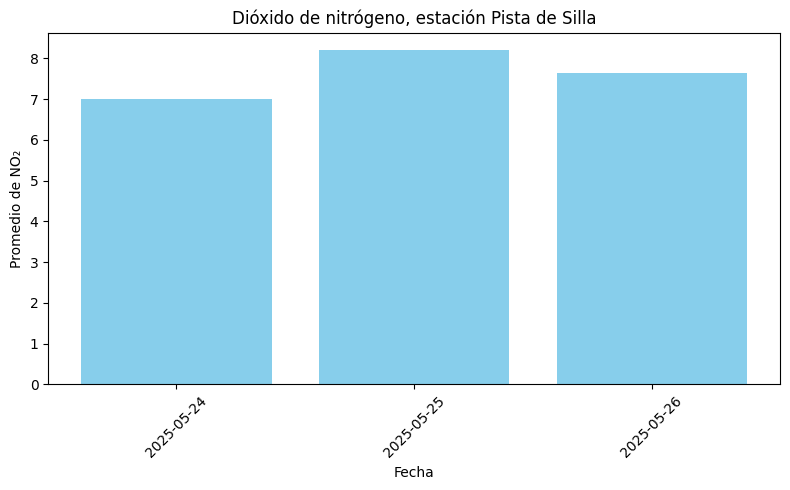

In [ ]:
# Datos
fechas = list(promedios.keys())
valores = list(promedios.values())

# Crear gráfica
plt.figure(figsize=(8, 5))
plt.bar(fechas, valores, color='skyblue')

# Etiquetas
plt.xlabel('Fecha')
plt.ylabel('Promedio de NO₂')
plt.title(f'Dióxido de nitrógeno, estación {df_filtrado["nombre"].iloc[0]}')
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar
plt.show()

## 05
Realizar gráfica con  la línea temporal de las mediciones de ozono de la estación del punto anterior. Pista, la columna 'fecha_carga' habría que cambiarla de tipo.

Extraemos las variables que nos importan

In [ ]:
df_o3 = df[['objectid', 'nombre', 'o3', 'fecha_carga']] # Seleccionar solo las columnas relevantes para analizar el ozono
display(df_o3.head(5))

,objectid,nombre,o3,fecha_carga
0,26,Pista de Silla,71.0,2025-05-24 20:20:06+00:00
1,28,Viveros,88.0,2025-05-24 20:20:08+00:00
2,431,Olivereta,NaN,2025-05-24 20:20:11+00:00
3,432,Patraix,NaN,2025-05-24 20:20:12+00:00
4,23,Francia,82.0,2025-05-24 20:20:04+00:00


Borramos los valores NaN ya que en o3 tenemos 216 non-null.

In [ ]:
df_o3 = df_o3[df_o3['o3'].notna()]
display(df_o3.head(5))

,objectid,nombre,o3,fecha_carga
0,26,Pista de Silla,71.0,2025-05-24 20:20:06+00:00
1,28,Viveros,88.0,2025-05-24 20:20:08+00:00
4,23,Francia,82.0,2025-05-24 20:20:04+00:00
5,27,Universidad Politécnica,82.0,2025-05-24 20:20:07+00:00
8,24,Boulevar Sur,83.0,2025-05-24 20:20:05+00:00


Despues filtramos la info por el objectid de la estacion deseada.

In [ ]:
df_o3 = df_o3[df_o3['objectid'].isin(df_max_co['objectid'])] # Filtra df_o3 para conservar solo las filas cuyo 'objectid' esté en df_max_co (estacion encontrada)
display(df_o3.head(5))

,objectid,nombre,o3,fecha_carga
0,26,Pista de Silla,71.0,2025-05-24 20:20:06+00:00
15,26,Pista de Silla,73.0,2025-05-24 23:20:07+00:00
28,26,Pista de Silla,75.0,2025-05-25 00:20:06+00:00
40,26,Pista de Silla,77.0,2025-05-25 01:20:06+00:00
51,26,Pista de Silla,79.0,2025-05-25 02:20:08+00:00


Cambiamos el objeto fecha_carga a date time para poder organizar los datos de menor a mayor y poder hacer la grafica.

In [ ]:
df_o3['fecha_carga'] = pd.to_datetime(df_o3['fecha_carga']) # Asegura que la columna 'fecha_carga' sea del tipo datetime
df_o3 = df_o3.sort_values(by='fecha_carga') # Ordena los datos por fecha para la visualización temporal
display(df_o3.head(5))

,objectid,nombre,o3,fecha_carga
0,26,Pista de Silla,71.0,2025-05-24 20:20:06+00:00
15,26,Pista de Silla,73.0,2025-05-24 23:20:07+00:00
28,26,Pista de Silla,75.0,2025-05-25 00:20:06+00:00
40,26,Pista de Silla,77.0,2025-05-25 01:20:06+00:00
51,26,Pista de Silla,79.0,2025-05-25 02:20:08+00:00


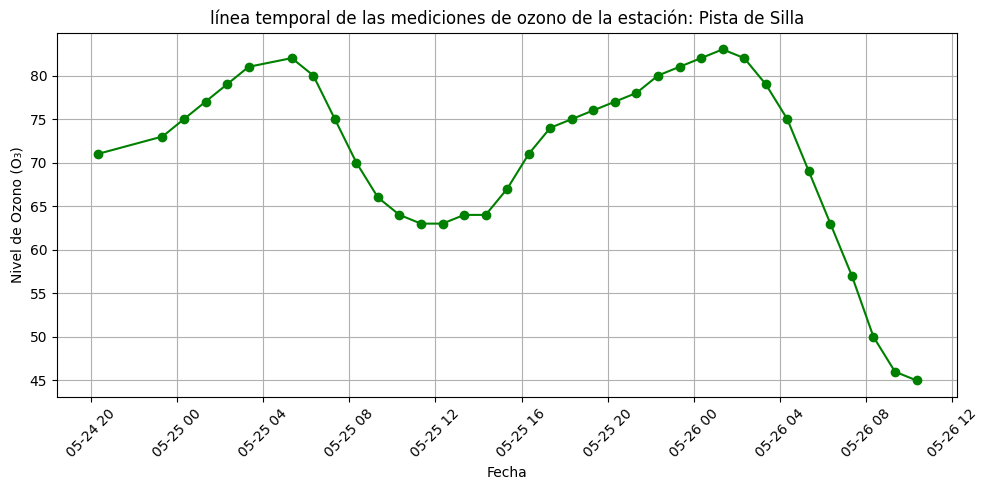

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df_o3['fecha_carga'], df_o3['o3'], marker='o', linestyle='-', color='green') # Graficar los valores de ozono a lo largo del tiempo

# Etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Nivel de Ozono (O₃)')
plt.title(f'línea temporal de las mediciones de ozono de la estación: {df_o3["nombre"].iloc[0]}')

# Ajustes visuales
plt.xticks(rotation=45) # Rota las etiquetas del eje X 45 grados para mejor legibilidad
plt.tight_layout() # Ajusta automáticamente los márgenes para que no se superpongan los elementos

# Mostrar gráfico
plt.grid(True)
plt.show()